<font size="+4">`Signal and Audio Processing`</font>

<font size="+3">`Seminar 07: Automatic Speech Recognition`</font>

<font size="+2">`Maks Nakhodnov & Dmitry Kropotov`</font>

<font size="+2">`Bremen, 2026`</font>

What you will learn from this notebook:

* Problem statement of speech recognition. Metrics. Datasets. Benchmarks.
* Encoder-only models. Granularity of input and output features.
* Soft alignment. CTC. CTC decoding. Acoustic models vs. Language models in decoding.

In [1]:
import io
import os

os.environ['TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL'] = '1'

from urllib.request import urlopen

import regex

import numpy as np

import torch
import torchaudio
import torchmetrics

import soundfile

import matplotlib.pyplot as plt

from IPython.display import Audio

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# `1. Introduction, Features, and the Alignment Problem`

## `1.1. ASR Problem Statement and Input Data`

**Automatic Speech Recognition (ASR)** or **Speech-to-Text (STT)** is the task of converting an audio recording into a sequence of text tokens. Unlike computer vision or NLP tasks, where inputs are usually discrete (pixels, words), the input for ASR is a continuous and **very long time series**. From a mathematical perspective, speech recognition is a *sequence-to-sequence* task.

![](https://images.netcomlearning.com/cms/images/real-world-applications-of-automatic-speech-recognition.jpg)

Let us consider an audio recording. In its raw form, it is a one-dimensional array of sound wave amplitudes $S = (\mathbf{s}_1, \mathbf{s}_2, \dots, \mathbf{s}_T), \quad \mathbf{s}_t \in \mathbb{R}$. However, feeding raw audio directly into a neural network is inefficient. The standard solution is to extract acoustic features. Then the task can be formulated as:

Let $X$ be the input sequence of acoustic features of length $M$, obtained from the sequence $S$:
$$S \longrightarrow X = (\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_M), \quad \mathbf{x}_t \in \mathbb{R}^D$$

The task of ASR is to find such a sequence of text tokens $Y$ of length $N$:
$$Y = (y_1, y_2, \dots, y_N), \quad y_n \in V$$
where $V$ is the vocabulary of tokens (characters, subwords, or words), which maximizes the conditional probability:
$$Y^* = \arg\max_{Y} P(Y | X)$$

In the extreme case, for raw waveform: $X = S, D = 1, M = T$.

*The complexity of the ASR task* lies partly in the physics of the data: background noise, overlapping voices (Cocktail party problem), regional accents, and variability in speech rate make the mapping $S \to Y$ non-trivial.

In previous classes, we discussed various ways to extract features from sound. As a standard, the industry has converged on using spectral features — **Log-Mel Spectrogram**.

The key issue when transitioning to the feature space is the balance between temporal compression and the dimensionality of the feature space. Log-Mel Spectrogram:
1. Due to the quasi-stationarity of real sound, we can apply the Short-Time Fourier Transform, which calculates the signal spectrum in a window, thereby **reducing temporal resolution**.
2. To simulate human ear perception, the spectrogram is converted to the mel scale. This removes redundancy and **compresses information in the feature space**.

![](https://www.researchgate.net/profile/Ascension-Gallardo-Antolin/publication/351844480/figure/fig1/AS:1032783619174405@1623246211664/Block-diagram-of-the-log-mel-spectrogram-computation-process.png)

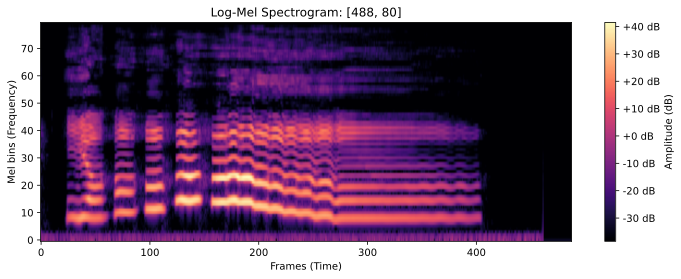

In [2]:
waveform, sample_rate = soundfile.read('./../../Tasks/Task 01/data/singing.wav')
waveform = torch.tensor(waveform, dtype=torch.float32)

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=1200,           # 25 ms * 48 kHz = 1200
    win_length=1200,      # Defaults to n_fft
    hop_length=480,      # Window step (stride). 10 ms * 48 kHz = 480
    n_mels=80,           # Number of Mel filters (bins)
    power=2.0            # 2.0 means power spectrogram
)
db_transform = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)

mel_spectrogram = mel_transform(waveform)
log_mel_spectrogram = db_transform(mel_spectrogram)

fig, ax = plt.subplots(figsize=(10, 4))

image = ax.imshow(log_mel_spectrogram.numpy(), origin='lower', aspect='auto', cmap='magma')
cbar = fig.colorbar(image, ax=ax, format="%+2.0f dB")
cbar.set_label("Amplitude (dB)")

ax.set_title(f"Log-Mel Spectrogram: {list(log_mel_spectrogram.T.shape)}")
ax.set_ylabel("Mel bins (Frequency)")
ax.set_xlabel("Frames (Time)")

plt.tight_layout()
plt.show()

1. The standard Window size is **$25$ milliseconds**. Within $25$ ms, the human vocal tract physically does not have time to change significantly, so the signal can be considered quasi-stationary.
2. The Stride/Hop size is **$10$ milliseconds**. With a step of $10$ ms, **1 second of audio turns into exactly $100$ frames** ($M = 100$).
3. The dimensionality of the feature space is determined by the number of Mel filters (Num Mels) and is usually $D = 80$.

If a person speaks a phrase that is $5$ seconds long, the matrix $X$ will have a size of $500 \times 80$. At the same time, the original audio with a sampling rate of $16$ kHz contains $2$ times more samples.  

Of course, to increase the dataset size, one can use natural augmentations of spectrograms:

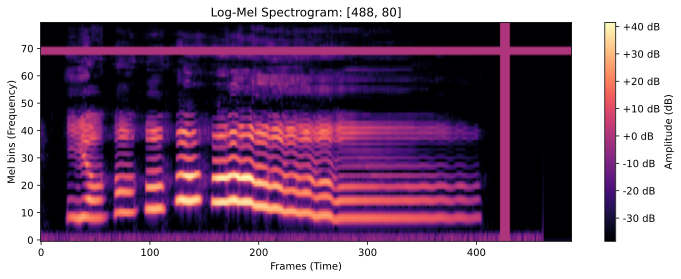

In [3]:
time_masking = torchaudio.transforms.TimeMasking(time_mask_param=20)
freq_masking = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)

fig, ax = plt.subplots(figsize=(10, 4))

image = ax.imshow(time_masking(freq_masking(log_mel_spectrogram)).numpy(), origin='lower', aspect='auto', cmap='magma')
cbar = fig.colorbar(image, ax=ax, format="%+2.0f dB")
cbar.set_label("Amplitude (dB)")

ax.set_title(f"Log-Mel Spectrogram: {list(log_mel_spectrogram.T.shape)}")
ax.set_ylabel("Mel bins (Frequency)")
ax.set_xlabel("Frames (Time)")

plt.tight_layout()
plt.show()

## `1.2. The Alignment Problem`

Suppose we have an audio recording of the phrase: *"Hello, world!"*, which the speaker pronounces in $1.5$ seconds:
* Text length (number of characters and spaces): $N = 10$.
* Length of the feature sequence (frames): $M \approx 150$.

There is a strong mismatch in lengths: $M \gg N$. Moreover, in the training set we have **no frame-level alignment**. We do not know exactly on which frame the letter "H" sounds, and where the speaker makes a pause. The neural network only receives the raw $150 \times 80$ matrix and the final string "Hello, world!".

This problem resembles a similar characteristic in machine translation, where the translation can have a different length than the original. However, unlike machine translation, where word order changes, in ASR the order remains monotonic. The difficulty lies elsewhere: **we do not know which frame $x_t$ corresponds to which character $y_n$.**

This is known as the **Unknown Alignment** problem:

$$
P(Y|X) = \sum_{A \in \mathcal{A}} P(Y, A | X)
$$

Where $A$ is a possible **alignment path**. We need to marginalize (sum) the probabilities over all possible ways to align characters with frames $\mathcal{A}$. In modern End-to-End systems, we want the model to learn **without explicit timing annotations** (when each character starts and ends), because collecting data for forced alignment on a large scale scales poorly.

At first glance, it seems that calculating this sum is exponentially complex; however, later we will show that this probability can be computed exactly in quadratic time.

In doing so, one of two approaches can be used:

1. **Latent / Hard Alignment**
   This approach assumes that there is a specific, but unknown, frame-by-frame correspondence between sound and text. During training, we marginalize (sum) the probabilities over all possible valid paths to compute the probability $P(Y|X)$, **enforcing strict monotonicity**. In this approach, we force the model to output a prediction for *each* of the $M$ frames. Since there are fewer characters than frames, the model is forced to generate empty tokens (Blank) or duplicate characters. We introduce a mathematical rule for collapsing duplicates.
   
   *Representatives:* Encoder-only, Encoder-Predictor models, **CTC** (Connectionist Temporal Classification), **RNN-T** (Transducer).

2. **Implicit Alignment**
   In this approach, we completely **abandon strict temporal binding to the audio axis and explicit path enumeration**. The model receives the entire matrix $X$ at once (Encoder), and then generates text (Decoder), using the spectrogram as external conditioning.

   *Representatives:* Encoder-Decoder, Decoder-only models: **Listen, Attend and Spell**, **OpenAI Whisper**, **Audio-LLM**.

## `1.3. ASR Metrics`

<b style='color:red;'>If we have trained a model, how do we know how well it works? Can we just use Accuracy?</b>

<details><summary>Answer:</summary>>> Using Accuracy is a bad idea. If the model outputs "Hullo" instead of "Hello", $\text{Accuracy} = 0\%$ at the word level, even though the model made only a one-letter mistake. We need to use partial match metrics. </details>

The standard metric is **Word Error Rate (WER)** for languages with word separators (spaces) or **Character Error Rate (CER)** for unspaced languages or to evaluate the quality of an acoustic model. The basis of these metrics is the **Levenshtein Distance** (Edit Distance).

**Levenshtein Distance** is the minimum number of editing operations required to transform the model's hypothesis into the reference.

*Note: Different definitions for Levenshtein Distance can be used depending on the task. For example, you can separately penalize word transpositions, ignoring case and special characters, and assign different weights to different types of errors.*

### `Word Error Rate`

Types of operations:
1.  **Insertion:** The model added an extra word.
2.  **Deletion:** The model missed a word.
3.  **Substitution:** The model confused a word.

$$
\text{WER} = \frac{S + I + D}{N}
$$

Where:
*   $S, I, D$ — the number of corresponding errors.
*   $N$ — the total number of words in the reference.

*Note 1: WER — the lower, the better.*

*Note 2: WER can be greater than $1$. This happens if the model generated a lot of "garbage" words (Insertions), so that $I + D \gg N$.*

Let's consider an example:

**Reference:** "on the way home heard a creak"

**Hypothesis:** "and on the way heard a knock"

Let's build an alignment:

| Operation | Reference Word | Hypothesis Word | Note |
| :--- | :--- | :--- | :--- |
| **I** | - | **and** | Insertion of an extra word |
| **C** | on | on | Correct |
| **C** | the | the | Correct |
| **C** | way | way | Correct |
| **D** | **home** | - | Missed word |
| **C** | heard | heard | Correct |
| **C** | a | a | Correct |
| **S** | creak | **knock** | Word substitution |

**Calculation:**
*   $S = 1$ (creak -> knock)
*   $I = 1$ (added "and")
*   $D = 1$ (removed "home")
*   $N = 7$ (words in the reference)

$$
\text{WER} = \frac{1 + 1 + 1}{7} = \frac{3}{7} \approx 0.43 \quad (43\%)
$$

It turns out that Levenshtein distance can be calculated efficiently using **dynamic programming**:

Let's consider an example:
*   **Reference:** `I LIKE CATS`
*   **Hypothesis:** `I LOVE THE CATS`

We build a distance matrix, where cell $(i, j)$ is the minimum number of edits to transform the substring $R[1..i]$ into $H[1..j]$.

1. If the words match: $\text{dp}[i][j] = \text{dp}[i-1][j-1]$ (cost 0).
2. If the words are different, we take $1 + \min$ of the neighbors:
   *   Left ($\text{dp}[i][j-1]$): **Insertion**
   *   Top ($\text{dp}[i-1][j]$): **Deletion**
   *   Diagonal ($\text{dp}[i-1][j-1]$): **Substitution**

| | # | I | LOVE | THE | CATS |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **#** | **0** | 1 | 2 | 3 | 4 |
| **I** | 1 | **0** | 1 | 2 | 3 |
| **LIKE** | 2 | 1 | **1** | 2 | 3 |
| **CATS** | 3 | 2 | 2 | **2** | **2** |


$$
\text{WER} = \frac{1 + 0 + 1}{3} = \frac{2}{3}
$$

Dynamic programming allows finding the **optimal** alignment in $\mathcal{O}(|R| \cdot |H|)$ operations.

### `Character Error Rate`

Calculated similarly to WER, but at the character level:
$$
\text{CER} = \frac{S_c + I_c + D_c}{N_c}
$$

CER is often used for languages like Chinese or for evaluating "raw" acoustic accuracy, since it penalizes less for spelling errors in words (e.g., "color" vs "colour") if the root is recognizable.

Besides CER/WER, SER (Sentence Error Rate) is sometimes used — the fraction of sentences that contain at least one error. This is useful for voice assistants: if a phrase is recognized with one error, the command might not be executed at all.

### `Text Normalization`

Before calculating metrics, it is **mandatory** to normalize both the Reference and Hypothesis to a common format.

You cannot compare:
* `"100 dollars"` (numbers) vs `"one hundred dollars"` (text).
* `"Hello!"` (punctuation) vs `"hello"` (without punctuation).
* `"U.S.A."` vs `"United States of America"` (different abbreviations).

Therefore, before calculating WER, a strict normalization pipeline is *always* applied:
1. Converting all numbers to written (or digital) form.
2. Removing all punctuation.
3. Lowercasing.
4. Expanding abbreviations.

Without this, WER will be artificially inflated due to differences in formatting, rather than actual recognition errors.

In [4]:
def normalize(text_list):
    num_map = {"2": "two", "1": "one", "3": "three"} 

    normalized = []
    for text in text_list:
        t = text.lower()
        t = t.replace("ё", "е")
        t = regex.sub(r'[^\w\s]', '', t)
        
        for num, word in num_map.items():
            t = t.replace(num, word)
            
        t = " ".join(t.split())
        normalized.append(t)
        
    return normalized
    
reference = ["At 2 pm it started raining heavily."]
hypothesis =["at two pm it started raining heavily"]

wer_metric = torchmetrics.text.WordErrorRate()
cer_metric = torchmetrics.text.CharErrorRate()

In [5]:
print('--- BEFORE NORMALIZATION ---')
print('WER: {0:.2f}'.format(wer_metric(hypothesis, reference)))
print('CER: {0:.2f}'.format(cer_metric(hypothesis, reference)))

print('--- AFTER NORMALIZATION ---')
print('WER: {0:.2f}'.format(wer_metric(normalize(hypothesis), normalize(reference))))
print('CER: {0:.2f}'.format(cer_metric(normalize(hypothesis), normalize(reference))))

--- BEFORE NORMALIZATION ---
WER: 0.43
CER: 0.14
--- AFTER NORMALIZATION ---
WER: 0.00
CER: 0.00


### `Dataset-level Metrics`

When calculating the metric for the entire dataset, you cannot simply calculate the WER for each sentence and take the arithmetic mean.

*Example:* You have a phrase of $1$ word and a phrase of $100$ words. An error in the short phrase will yield a $100\%$ WER, and in the long one — a $1\%$ WER. The average would be $50.5\%$, which does not reflect the real quality.

**Accumulated WER:** you need to sum all the errors ($S, D, I$) over the entire dataset and divide by the total sum of all words ($N$) in all reference texts.

$$\text{WER}_{\text{dataset}} = \frac{\sum S_i + \sum D_i + \sum I_i}{\sum N_i}$$

### `RTF/RTFx`

In addition to quality metrics, ASR models are always evaluated using speed metrics:

* **RTF (Real-Time Factor):** The ratio of the time taken to process the audio to the duration of the audio itself.

$$\text{RTF} = \frac{\text{Processing Time}}{\text{Audio Duration}}$$

*   **$\text{RTF} = 1$**: The model operates at the speed of human speech.
*   **$\text{RTF} < 1$**: The model operates faster than real-time. This is critical for **Streaming ASR**.
*   **$\text{RTF} > 1$**: The model operates slower than real-time. Suitable only for offline processing.

* **RTFx (Real-Time Factor x):** Sometimes performance is indicated as a "speed multiplier" (**RTF Speed-up**). This is the reciprocal of RTF.

$$\text{RTFx} = \frac{1}{RTF} = \frac{\text{Audio Duration}}{\text{Processing Time}}$$

*   If they say: "The model works at **20x** speed", it means $\text{RTFx} = 20$.
*   This is equivalent to $\text{RTF} = 0.05$. That is, the model processes $1$ hour of audio in $3$ minutes.

Typical $\text{RTFx}$ values for modern models are $\gtrapprox 100$.

## `1.4. Datasets`

### `Public Datasets for Model Training`

| Dataset Name | Size (Hours) / Examples | Source (Domain) | Data Quality | Link |
| :--- | :--- | :--- | :--- | :--- |
| **LibriSpeech** | 960 h. / ~290k phrases | Audiobooks (LibriVox), reading aloud | **High (Studio).** Clean speech, single speaker, no noise. Historical standard. | [OpenSLR](https://www.openslr.org/12) |
| **GigaSpeech** | 10,000 h. (XL) | Podcasts, YouTube, audiobooks | **Mixed (Real-world).** Contains spontaneous speech, noise, interruptions. Labeled with quality assessment (WER). | [GigaSpeech](https://github.com/SpeechColab/GigaSpeech) |
| **Common Voice** | > 30,000 h. (all languages) / millions | Crowdsourcing (people read text from screen) | **Medium.** Many accents, different microphones, annotation errors occur. | [Mozilla CV](https://commonvoice.mozilla.org/) |
| **The People's Speech** | 30,000 h. | Internet audio with CC license, subtitles | **Noisy (In-the-wild).** "Dirty" dataset. A lot of background noise and inaccurate subtitles (pseudo-labels). |[HuggingFace](https://huggingface.co/datasets/MLCommons/peoples_speech) |
| **TED-LIUM 3** | 452 h. | Presentations at TED Talks | **Good.** Spontaneous speech, but professional microphones. Specific vocabulary. | [OpenSLR](https://huggingface.co/datasets/kfajdsl/tedlium/) |
| **Switchboard / Fisher** | ~300 h. / ~2000 h. | Telephone conversations between strangers | **Low (8kHz).** Spontaneous speech, echo, interruptions, disfluencies. (*Requires LDC license, but standard in papers*). | [LDC](https://catalog.ldc.upenn.edu/LDC97S62) |
| **VoxPopuli** | 400,000 h. (unlabeled) / 1,800 h. (labeled) | European Parliament sessions (23 languages) | **High.** Formal speech, many accents (non-native speakers), complex terminology. | [HuggingFace](https://huggingface.co/datasets/facebook/voxpopuli) |
| **Multilingual LibriSpeech (MLS)** | 50,000 h. (8 languages) | Audiobooks (LibriVox) in different languages | **High.** Analog of standard LibriSpeech, but for multilingual models. | [OpenSLR](https://www.openslr.org/94/) |
| **AISHELL-1 / 2 / 3** (*CN*) | 178h (v1) / 1000h (v2) / 85h (v3) | Studio recordings / call emulation | **High.** Standard for Chinese ASR. Read text and spontaneous speech. | [OpenSLR](https://www.openslr.org/33/) |
| **Golos** *(RU)* | 1,240 h. / ~1.5m. | Crowdsourcing (Sber), queries to assistants | **Medium/Good.** Short commands and phrases. Excellent basic dataset for the Russian language. | [GitHub / HF](https://github.com/salute-developers/golos) |
| **Open STT** *(RU)* | ~20,000 h. | YouTube, radio, calls, books | **Mixed.** Huge compilation from different domains. Locally very noisy annotation. | [OpenSTT](https://github.com/snakers4/open_stt) |

* LibriSpeech is ideal for getting started and testing hypotheses, but is "too clean".
* GigaSpeech and VoxPopuli are needed for real production models.
* For Self-Supervised Learning, massive unlabeled datasets are used, such as Libri-Light (60k hours) or VoxPopuli Unlabeled (400k hours).

### `Public Datasets for Model Evaluation`

| Name | Language | Source / Domain | Difficulty | Target WER/CER | Note |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **LibriSpeech**<br>`test-clean` | EN | Audiobooks | Low | **1.4% – 2.0%** | Gold standard benchmark. Below 2% is considered "super-human" level. |
| **LibriSpeech**<br>`test-other` | EN | Audiobooks | Medium | **2.6% – 3.5%** | Test for accents and noise. Good result is < 4%. |
| **Switchboard**<br>`Eval2000` | EN | Telephone (dialogue) | Medium | **5.8% – 8.0%** | Spontaneous speech. Classic result of top models ~6-7%. |
| **CALLHOME** | EN | Telephone (family) | High | **11.0% – 15.0%** | Slang, emotiveness. Harder than Switchboard. |
| **TED-LIUM v3**<br>`Test` | EN | Presentations | Medium | **4.0% – 5.0%** | Public speeches, terminology. |
| **GigaSpeech**<br>`Test` | EN | Podcasts, YouTube | Medium | **10.0% – 12.0%** | "Wild" internet. Quality highly depends on the model (Whisper ~9-10%). |
| **CHiME-6**<br>`Test` | EN | Dinner parties at home | Extreme | **20.0% – 26.0%** | Noise, speech overlaps. Very difficult dataset. |
| **FLEURS (RU)** | RU | Wikipedia (reading) | Low | **3.0% – 5.0%** | Clean read speech. Main benchmark for multilingual models. |
| **AISHELL-1**<br>`Test` | CN | Studio recordings | Low | **3.0% – 4.0% (CER)** | Gold standard for Chinese. |
| **HKUST** | CN | Telephone (conversations) | High | **18.0% – 20.0% (CER)** | Conversational Chinese, noise. |
| **Golos**<br>`Test` | RU | Crowdsourcing | Medium | **2.0% – 3.0%** | Clean recordings. GigaAM-v2 shows ~2.2%. |
| **Golos**<br>`Farfield Test` | RU | Smart speakers | High | **13.0% – 16.0%** | Reverberation. GigaAM-v2: 13.3%. Whisper-v3: ~18%. |
| **OpenSTT**<br>`Test` | RU | Movies, YouTube | High | **10.0% – 15.0%** | Real data. GigaAM-v2: ~10.3%. Whisper-v3: ~14.4%. |
| **Common Voice**<br>`Test (Ru)` | RU | Crowdsourcing | Medium | **5.5% – 7.0%** | Variety of speakers, but clean sound. GigaAM-v2: 5.5%. |
| **RuLS**<br>`Test` | RU | Audiobooks | Low | **2.7% – 5.0%** | LibriSpeech analog. GigaAM-v2: ~2.7%. |

It is important to note that the ASR task is extremely heterogeneous in terms of input data quality. Therefore, to evaluate the quality of a model, it is necessary to look not only at In-Domain quality, but also at Out-Domain (Zero-shot) quality. A classic example is the Whisper model, which was the first to show Superhuman quality in **Zero-shot mode**, demonstrating the model's high robustness to audio recording conditions.

<img src="https://pub.mdpi-res.com/applsci/applsci-16-03399/article_deploy/html/images/applsci-16-03399-g008.png?1775125592" width="1000"/>

### `Data Volumes of SOTA Models`

| Model | Labeled Data | Unlabeled Data | Training Type | WER (LS test-other)
| :--- | :--- | :--- | :--- | :--- |
| **DeepSpeech 2** | $~12.000$ h. | — | Supervised | $13.25\%$ |
| **Wav2Vec 2.0** | $960$ h. | $60.000$ h. | Self-Supervised | $5.0\%$ (Large + LM) |
| **HuBERT** | $960$ h. | $60.000$ h. | Self-Supervised | $3.9\%$ (Large + LM) |
| **Whisper** | $680.000$ h. | — | Weakly Supervised | $5.4\%$ (Zero-Shot, Large) |
| **USM** | $~100.000$ h. | $12M$ h. | SSL + Supervised | — |
| **SeamlessM4T** | $\sim 400.000$ h. | $1M$ h. | Multimodal / SSL | — |
| **Whisper v3** | $\sim 1.000.000 - 5.000.000$ h. | — | Weakly Supervised | $3.9\%$ (Zero-Shot, Large) |
| **Parakeet** | $670.000$ h. | — | Weakly Supervised | $3.5\%$ (Zero-Shot, 0.6B) |
| **Qwen3-Omni** | $\sim 20.000.000$ | — | Weakly Supervised | $2.48\%$ (Zero-Shot) |

# `2. Encoder-only Models`

Let's consider typical representatives of Latent Alignment ASR — Encoder-only models. The encoder's task is to transform a long sequence of frames $X$ into a semantically rich representation and determine the optimal alignment between the frames and the ground truth text.

Let our Encoder be a function $f_{\theta}$ that transforms input features $X$ into a sequence of hidden representations $H$:
$$
X = (\mathbf{x}_1, \dots, \mathbf{x}_M) \overset{f_{\theta}}{\longrightarrow} H = (\mathbf{h}_1, \dots, \mathbf{h}_{M^{\prime}})
$$

### `2.1. Subsampling`

Before feeding the spectrogram into layers with global context, we need to solve two problems:
1.  **High sampling rate:** $100$ frames per second is too much. For a $30$-second phrase, the feature matrix will be $3000 \times D$. If global context is implemented via an attention mechanism, the processing complexity will be $O(M^2)$, which is highly resource-intensive.
2.  **Local context:** The speech signal changes smoothly, and adjacent frames are highly correlated.

The first layers of the encoder solve the problem of reducing the frame rate. Usually, the rate is reduced by $4$ or $8$ times.
If $X$ has a rate of $100$ fps, and $\text{stride} = 4$, the output is $25$ fps. Thus, we not only save memory, but also force each vector $\mathbf{h}_i$ to describe a broader sound context ($40$–$80$ ms).

To downsample, 1D/2D convolutions with a stride greater than $1$ are usually used.

### `2.2. Comparison of Encoder Architectures`

| **Deep Speech 2** | **Jasper** | **QuartzNet** | **Conformer** |
| :---: | :---: | :---: | :---: |
| <img src="https://www.researchgate.net/publication/370763497/figure/fig4/AS:11431281158305169@1684119875354/Architecture-of-Deep-Speech-2-62.ppm" width="280" alt="DeepSpeech 2"> | <img src="https://docs.nvidia.com/nemo-framework/user-guide/latest/_images/jasper_vertical.png" width="280" alt="Jasper"> | <img src="https://docs.nvidia.com/nemo-framework/user-guide/latest/_images/quartz_vertical.png" width="280" alt="QuartzNet"> | <img src="https://docs.nvidia.com/nemo-framework/user-guide/latest/_images/conformer_ctc.png" width="280" alt="Conformer"> |
| **2015 year** | **2019 year** | **2019 year** | **2020 year** |
| $\sim 38$M parameters | $\sim 333$M parameters | $\sim 19$M parameters | $\sim 120$M parameters (Large) |
| LSTM/GRU | 1D Convolutions | Depthwise Separable CNN | Attention + CNN |

1.  **Deep Speech 2:** The first large End-to-End model. Very computationally heavy to train due to recurrent layers, which parallelize poorly on GPUs.
2.  **Jasper:** Transition to a fully convolutional architecture. This allowed a massive speedup in training and inference by using only 1D convolutions.
3.  **QuartzNet:** An improved version of Jasper. By using **Depthwise Separable Convolutions**, it managed to reduce the number of parameters by almost $20$ times while maintaining the same quality.
4.  **Conformer:** The current SOTA standard. Instead of choosing between CNNs and Transformers, it combines them: convolutions effectively extract local features (phonemes), and Self-Attention finds global dependencies in long phrases.

## `2.3. Modeling Units. Characters vs Subwords`

After transforming the input spectrogram into a set of feature vectors $H$, the model must convert them into a text representation. Similarly to text models, the question arises of how to correctly choose the granularity of the model's predictions.

The simplest option is to use **characters** as tokens:
* **Vocabulary size:** Small ($|V| \approx 30-50$).

Problems:
1. **Long sequences:** If a phrase consists of $10$ words, it is approximately $50$ characters. The model needs to make $50$ generation steps.
2. **Weak language model:** The model sees the letter 's' after 't' and needs to understand its syntactic role. It is hard for it to "see" the whole word.

A more modern option is **subword units** (Subwords / BPE / SentencePiece):
* **Vocabulary size:** You can choose the granularity depending on the available resources in a wide range, from hundreds to hundreds of thousands of tokens.
  
  For example, the **Byte Pair Encoding (BPE)** algorithm breaks rare words into frequent parts (subwords), while leaving frequent words whole until the vocabulary reaches the desired number of tokens.

Subword models converge faster and yield lower WER.
* It is more efficient to predict syllables than letters. This reduces the load on the alignment mechanism.
* A language model on subwords is much more powerful than a character-level N-gram LM.

On small datasets, Character-level tokenization usually performs better ([Pushing the Limits of Non-Autoregressive Speech Recognition](https://arxiv.org/pdf/2104.03416)), however, as the dataset size increases, Subwords quickly begin to win and are currently the standard.

| Характеристика | | | | | | | | | | | | |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Type** | Base | Base | Base | Base | Base | Base | Pre-train | Pre-train | Pre-train | Pre-train | Pre-train | Pre-train |
| **Size** | 9M | 9M | 28M | 28M | 116M | 116M | 120M | 120M | 582M | 582M | 1017M | 1017M |
| **Vocab** | Subword | Char | Subword | Char | Subword | Char | Subword | Char | Subword | Char | Subword | Char |
| **dev93** | $$22.9$$ | $$14.0$$ | $$34.9$$ | $$15.9$$ | $$40.9$$ | $$21.0$$ | $$8.5$$ | $$6.4$$ | $$6.5$$ | $$\bf5.1$$ | $$7.1$$ | $$4.8$$ |
| **test92** | $$19.4$$ | $$11.8$$ | $$30.5$$ | $$12.2$$ | $$36.2$$ | $$16.7$$ | $$5.7$$ | $$4.6$$ | $$4.4$$ | $$\bf3.4$$ | $$5.8$$ | $$4.0$$ |

**The Connection Between Subsampling and BPE:**

There is a balance between input frequency and prediction granularity:
If we compress the audio by $4$ times to $25$ frames per second.
*   A person speaks $\approx 2-3$ words per second.
*   If we use characters, we need to output $\sim 15$ tokens per second. $25 > 15$, no problem.
*   If we use subword units, we need to output $ \sim 3-4$ tokens per second. $25 \gg 4$. This allows the model to vary how it predicts tokens more flexibly.

For fast models utilizing extreme time compression, e.g., stride $8 \Rightarrow 12$ tokens per second $\Rightarrow$ one must use BPE!

For example, Fast Conformer:[Fast Conformer with Linearly Scalable Attention for Efficient Speech Recognition](https://arxiv.org/pdf/2305.05084).

| Encoder | WER, % test-other | Inference, samples/s | Params, M | GMACS |
| :--- | :---: | :---: | :---: | :---: |
| Baseline Conformer | $$5.19$$ | $$169$$ | $$115$$ | $$143.2$$ |
| +8X Stride | $$5.11$$ | $$303$$ | $$115$$ | $$92.5$$ |
| +Depthwise conv | $$5.12$$ | $$344$$ | $$111$$ | $$53.2$$ |
| +256 channels | $$5.09$$ | $$397$$ | $$109$$ | $$48.8$$ |
| +Kernel 9 | $$\bf 4.99$$ | $$\bf 467$$ | $$\bf 109$$ | $$48.7$$ |

## `2.4. Self-Supervised Learning (SSL) in Audio. wav2vec 2.0. HuBERT`

Before proceeding to model training, it is necessary to determine what data is available for training. For audio, $3$ main types of data can be distinguished:

1. **Labeled**. Classic audio-text pairs. Expensive to collect and limited in quantity, but they carry the main useful signal. 
   * **Synthetic**. Automatically generated data for ASR can be used as a cheap way to expand the dataset, especially for low-resource languages.
2. **Weakly-labeled**. Data where the connection between text and audio is weak, in particular, incomplete, noisy transcriptions, as well as contextual information, e.g., video titles, descriptions, tags. They allow adding a link between audio and language to the model, and improving quality through the large volume of such datasets.
3. **Unlabeled**. Data for which there is no annotation. This is the most abundant type of data, but it only allows learning acoustic information.
    * **Pseudo-Labeled**. Using a current ASR model, one can label unlabeled data and use an external quality assessment system to select the best results for the training set.
  
As the size of ASR models grows, the problem of a lack of labeled data for **Supervised Learning** arises. Audio labeling is an expensive and lengthy process. Creating a good supervised model requires tens of thousands of hours of labeled data. At the same time, there are millions of hours of unlabeled audio on the internet (podcasts, YouTube, radio). 

**Can we force the encoder to learn the structure of human speech (phonetics, intonations, word boundaries) solely from raw audio, without text?**

In NLP, a similar task of learning language structure on unlabeled data was solved using BERT-like models. Let's try to apply a similar approach in ASR, allowing the model to learn the structure of speech on massive arrays of *unlabeled* data, and then quickly adapt to the recognition task on a small number of *labeled* examples.

The idea consists of two stages:
1. **Pre-training:** Using large arrays of audio without text, we train the encoder to predict masked audio frames, learning a semantically rich hidden representation for the sound.
2. **Fine-tuning:** We take this pre-trained acoustic model and fine-tune it on a small labeled dataset.

Unlike discrete tokens in NLP, audio representation (both via raw waveform and spectrogram frames) is continuous. This prevents directly transferring BERT's logic to train Masked encoders.

<table style="width: 100%; border-collapse: collapse; text-align: center; font-family: sans-serif;">
  <!-- Заголовки (названия моделей) -->
  <tr>
    <th style="width: 33%; padding: 15px; font-size: 1.1em; border: none;">Wav2Vec 2.0<br>https://arxiv.org/pdf/2006.11477</th>
    <th style="width: 33%; padding: 15px; font-size: 1.1em; border: none;">HuBERT<br>https://arxiv.org/pdf/2106.07447</th>
    <th style="width: 33%; padding: 15px; font-size: 1.1em; border: none;">Masked Contrastive Model<br>https://arxiv.org/abs/2110.07313</th>
  </tr>
  
  <!-- Строка для цельной картинки на все 3 колонки -->
  <tr>
    <td colspan="3" style="padding: 20px; border: none; border-bottom: 1px solid #ddd;">
      <img src="./SSL.svg" alt="Схема архитектур" style="width: 100%; max-width: 1400px; height: auto;">
    </td>
  </tr>
  
  <!-- Год (светло-серый фон) -->
  <tr style="background-color: #f2f2f2; font-weight: bold;">
    <td style="padding: 15px; border: none;">2020 year</td>
    <td style="padding: 15px; border: none;">2021 year</td>
    <td style="padding: 15px; border: none;">~ 2019-2020 year</td>
  </tr>
  
  <!-- Параметры (белый фон) -->
  <tr>
    <td style="padding: 15px; border: none;">$\sim 95$M (Base) / $\sim 317$M (Large) parameters</td>
    <td style="padding: 15px; border: none;">$\sim 95$M (Base) / $\sim 317$M (Large) parameters</td>
    <td style="padding: 15px; border: none;">$\sim 90$M parameters</td>
  </tr>
  
  <!-- Тип архитектуры (светло-серый фон) -->
  <tr style="background-color: #f2f2f2;">
    <td style="padding: 15px; border: none;">1D Convolutions + Transformer<br><i>(Contrastive Loss + Quantization)</i></td>
    <td style="padding: 15px; border: none;">1D Convolutions + Transformer<br><i>(Cross-Entropy + pseudo-labels K-means)</i></td>
    <td style="padding: 15px; border: none;">Feature Encoder + Transformer<br><i>(on Log-mel spectrograms)</i></td>
  </tr>
</table>

### `Contrastive Learning. wav2vec 2.0`

**wav2vec 2.0** solves the problem of continuous representation using **Quantization** and **Contrastive Learning**.

1. **Feature Encoder:** A CNN encoder compresses the Raw Waveform into a sequence of latent vectors $Z = (\mathbf{z}_1, \dots, \mathbf{z}_T)$ with a frequency of $\sim 50$ Hz.
2. **Masking:** A portion of the vectors $Z$ (about $50\%$) is replaced with a special mask vector.
3. **Context Network:** A Transformer receives the masked sequence and outputs contextualized vectors $C = (\mathbf{c}_1, \dots, \mathbf{c}_T)$.
4. **Quantization Module:** The vectors $Z$ are passed in parallel through a vector quantization module, which turns the continuous vector $\mathbf{z}_t$ into a discrete token $\mathbf{q}_t$ from a trainable dictionary. Quantization removes all continuous, unimportant information (noise, exact timbre, wave phase). The remaining discrete token contains only a coarse acoustic category.

**InfoNCE Loss:**
For the masked step $t$, the Transformer outputs the vector $\mathbf{c}_t$. The model must learn to distinguish the *true* quantized vector $\mathbf{q}_t$ from a set of $K$ random distractor vectors (negative examples) $\tilde{\mathbf{q}}$, taken from other masked parts of the audio.

$$ \mathcal{L}_m = -\log \frac{\exp(\text{sim}(\mathbf{c}_t, \mathbf{q}_t) / \kappa)}{\sum\limits_{\tilde{\mathbf{q}} \in \mathbf{Q}_t} \exp(\text{sim}(\mathbf{c}_t, \tilde{\mathbf{q}}) / \kappa)} $$
where $\text{sim}(\cdot)$ is cosine similarity, $\kappa$ is temperature.

<b style='color:red;'>Why does wav2vec 2.0 use a contrastive loss rather than predicting MSE directly on the spectrogram?</b>

<details><summary>Answer:</summary>>> 
Predicting the exact values of the spectrogram (or audio wave) via MSE forces the model to spend immense capacity reconstructing audio details: background noise, voice timbre, phase distortions. Contrastive loss forces the model to focus only on the differences between frames, learning high-level phonetic information while ignoring noise.
</details>

In [6]:
from transformers import Wav2Vec2Model

device = torch.device('cuda:0')

resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000).to(device)
wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base", dtype=torch.float16).to(device)

wave = resampler(waveform.unsqueeze(0).to(device))
embeddings = wav2vec2(wave.to(dtype=torch.float16))

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
# Frame Rate = 16000 / 320 = 50 frames per second
wave.shape, embeddings.last_hidden_state.shape, 77958 / 16000 * 50

(torch.Size([1, 77958]), torch.Size([1, 243, 768]), 243.61875)

In [8]:
wav2vec2

Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

### `HuBERT`

Training models with contrastive loss, especially with quantization modules, is often highly unstable. As an alternative, it was proposed to abandon Online quantization and instead pre-discretize the audio into a sequence of tokens. In this setup, we can drop the contrastive loss and use a standard BERT-like training process.

**Step 1: Creating pseudo-labels**

We cluster the audio dataset frames (for example, **K-Means** with $K=100$ clusters) based on classical acoustic features (e.g., MFCC). Then each audio frame $\mathbf{x}_t$ receives a discrete cluster label $z_t \in \{1, \dots, K\}$.

The resulting pseudo-text can be used for training in Masked-LM mode.

**Step 2: Masked Prediction**
1. Take the audio, pass it through a CNN.
2. Mask some of the frames along the time axis.
3. The Transformer attempts to predict the discrete class $z_t$ for the masked frames using a standard **Cross-Entropy Loss**.

$$ \mathcal{L} = -\sum_{t \in \mathcal{M}} \log p_t(z_t | \tilde{X}) $$
where $\mathcal{M}$ are the indices of the masked frames, $\tilde{X}$ is the masked input.

**Iterative refinement:**
The quality of the final model naturally depends on the quality of the clustering. MFCC features only allow for coarse frame clustering, which should be worse than the latent representations of the trained model. An iterative clustering procedure can be used: after training HuBERT on MFCC clusters, the internal embeddings of the model are used for more accurate clustering ($K^{next} \gg K$).

<b style='color:red;'>If pseudo-labels are calculated for each frame before training, why mask the input $\tilde{X}$? Why not train the model to predict $z_t$ from $\mathbf{x}_t$?</b>

<details><summary>Answer:</summary>>> 
If we don't mask the input, the model will learn a trivial identity transformation, as all the information to predict $z_t$ can be extracted directly from $\mathbf{x}_t$. Masking forces the model to rely on context.
</details>

In [9]:
from transformers import HubertModel

device = torch.device('cuda:0')

resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000).to(device)
hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960").to(device)

wave = resampler(waveform.unsqueeze(0).to(device))
embeddings = hubert(wave)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [10]:
hubert

HubertModel(
  (feature_extractor): HubertFeatureEncoder(
    (conv_layers): ModuleList(
      (0): HubertGroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x HubertNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x HubertNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): HubertFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): HubertEncoder(
    (pos_conv_embed): HubertPositionalConvEmbedding(
      (conv): Para

In [11]:
# Frame Rate = 16000 / 320 = 50 frames per second
wave.shape, embeddings.last_hidden_state.shape, 77958 / 16000 * 50

(torch.Size([1, 77958]), torch.Size([1, 243, 768]), 243.61875)

# `3. CTC`

So, the Encoder has compressed the audio and output a sequence of hidden states $H = (h_1, \dots, h_{M^{\prime}})$. Now we need to turn them into text.

The simplest way is to predict a character for each frame. Let the model output a probability distribution over the alphabet for each time step $t$.

But this approach has two problems:
1. **Duplication:** In the word "course", the sound "u" lasts a long time. The model will predict: `c-o-u-u-u-r-s-e`.
2. **Silence:** In the pauses between words, the model should stay silent, but there is no token in the dictionary to indicate silence.

**CTC** introduces a special **Blank** token ($\varepsilon$). It means "no character".

**Collapsing Function $B$:**
1.  Remove all consecutively repeating characters.
2.  Remove all Blank tokens.

**Example:**
*   Prediction: c-o-u-u-$\varepsilon$-r-s-s-$\varepsilon$-e-$\varepsilon$.
*   Step 1 (collapsing): c-o-u-$\varepsilon$-r-s-$\varepsilon$-e-$\varepsilon$.
*   Step 2 (removing blank): `c-o-u-r-s-e`.

<b style='color:red;'>How will the model predict the word "summer"? It has two 'm's in a row!</b>

<details><summary>Answer:</summary>
>> CTC does not collapse characters separated by a Blank.
    
Example path for "summer": s-u-u-m-m-$\varepsilon$-m-e-r:
* After collapsing: s-u-m-$\varepsilon$-m-e-r.
* After removing blank: `s-u-m-m-e-r`.
  
Thus, Blank acts as a separator for identical characters. </details>


<b style='color:red;'>How will the stride in the encoder affect the length of the output sequence and its contents?</b>

<details><summary>Answer:</summary>
>> 
    
*   If the stride is small (long audio), CTC will output many Blanks.
*   If the stride is too large (heavy compression), we may lose short sounds. Therefore, a stride of $8$ is the practical limit.
</details>

## `3.1. CTC Loss`

Now, having defined the extended vocabulary $\hat{V} = V \cup \{\varepsilon \}$, let's assume that the model predicts a probability distribution of tokens in this frame for each frame representation $h_{t}$.

*An important simplification of Encoder-only models is Contextual Independence of outputs. That is, the output for each frame does not depend on the outputs of other frames.*

Then, if $p_t(a | X)$ is the probability of token $a \in \hat{V}$ for frame $t$. By the property of Contextual Independence:
$$
P(A|X) = \prod_{t=1}^{M^{\prime}} p_t(a_t | X)
$$

During training, we know the correct text $Y$, but we do not know how it is located in time. CTC solves this by summing the probabilities of **all possible paths** that decode into the correct text:

$$
P(Y|X) = \sum_{A \in B^{-1}(Y)} P(Y, A | X) = \sum_{A \in B^{-1}(Y)} P(A | X) = \sum_{A \in B^{-1}(Y)} \prod_{t=1}^{M^{\prime}} p_t(a_t | X)
$$

Since the number of paths $|\{A | A \in B^{-1}(Y)\}|$ is exponentially large, the **Forward-Backward** algorithm is used to efficiently compute this sum.

<img src="./CTC-Encoder.svg" width="1000"/>

## `3.2. Forward-Backward CTC`

Consider a $10$-second audio. Taking STFT into account, we get about $1000$ frames in the spectrogram and $\sim 250$ frames at the encoder output. Considering the English alphabet: $|\hat{V}| = 30$. Then the cardinality of the set of all paths is $|\mathcal{A}| \sim 30^{250}$. Iterating through all paths directly is impossible, however, we can leverage the **monotonicity property of alignment**.


<img src="./CTC-Paths.svg" width="1000"/>

$$ \color{red} P(A_{1}) = P(h-e-l-\varepsilon -l-o-\ -w-o-r-l-d- \varepsilon - \varepsilon - \varepsilon - \varepsilon) = a^{1}_{h} \cdot a^{2}_{e} \cdot a^{3}_{l} \cdot a^{4}_{\varepsilon} \cdot a^{5}_{l} \cdot a^{6}_{o} \cdot a^{7}_{\ } \cdot a^{8}_{w} \cdot a^{9}_{o} \cdot a^{10}_{r} \cdot a^{11}_{l} \cdot a^{12}_{d} \cdot a^{13}_{\varepsilon} \cdot a^{14}_{\varepsilon} \cdot a^{15}_{\varepsilon} \cdot a^{16}_{\varepsilon}$$
$$ \color{green} P(A_{2}) = P(\varepsilon - \varepsilon - \varepsilon - h - e - \varepsilon - l - \varepsilon - l - o - \ - w - o - r - l - d) = a^{1}_{\varepsilon} \cdot a^{2}_{\varepsilon} \cdot a^{3}_{\varepsilon} \cdot a^{4}_{h} \cdot a^{5}_{e} \cdot a^{6}_{\varepsilon} \cdot a^{7}_{l} \cdot a^{8}_{\varepsilon} \cdot a^{9}_{l} \cdot a^{10}_{o} \cdot a^{11}_{\ } \cdot a^{12}_{w} \cdot a^{13}_{o} \cdot a^{14}_{r} \cdot a^{15}_{l} \cdot a^{16}_{d}$$
$$ \color{blue} P(A_{3}) = P(h - h - e - e - l - l - \varepsilon - l - o - \ - w - o - r  - l - d - \varepsilon) = a^{1}_{h} \cdot a^{2}_{h} \cdot a^{3}_{e} \cdot a^{4}_{e} \cdot a^{5}_{l} \cdot a^{6}_{l} \cdot a^{7}_{\varepsilon} \cdot a^{8}_{l} \cdot a^{9}_{o} \cdot a^{10}_{\ } \cdot a^{11}_{w} \cdot a^{12}_{o} \cdot a^{13}_{r} \cdot a^{14}_{l} \cdot a^{15}_{d} \cdot a^{16}_{\varepsilon} $$

$$
P(\text{hello world}) = \color{red} P(A_{1}) + \color{green} P(A_{2}) + \color{blue} P(A_{3}) \color{black}  + ... = \sum_{A \in B^{-1}(\text{hello world})} P(A | X)
$$

<img src="./CTC-Alignment.svg" width="1000"/>

To compute the probability $P(Y|X)$, we use dynamic programming over a 2D table:

* For the first dimension, we consider the extended sequence $\hat{Y} = \{\varepsilon, y_{1}, \varepsilon, y_{2}, ..., \varepsilon, y_{N}, \varepsilon \}$.
* For the second axis, we will use the number of frames in the encoder output $M^{\prime}$.

Size of the resulting table: $|\hat{Y}| \times M^{\prime} = (2 N + 1) \times M^{\prime}$.

The value in cell $\alpha[s, t]$ is the **total probability** of all paths that lead to position $s$ of sequence $\hat{Y}$ in $t$ steps.

<img src="./CTC-Forward.svg" width="1000"/>

The dynamics of filling the matrix $\alpha[s, t]$ depend on the type of the current character $\hat{y}_s$:

1.  **Stay on the current character:**

    We can stay in the same state $s$.
    *   Transition: $\alpha[s, t-1] \to \alpha[s, t]$.
    *   *Meaning:* Time passes ($t-1 \to t$), but the position in the text does not change ($s \to s$).

2.  **Move to the next character:**

    We can move from the previous state to the current one.
    *   Transition: $\alpha[s-1, t-1] \to \alpha[s, t]$.
    *   *Meaning:* Time passes ($t-1 \to t$), the position in the text shifts ($s-1 \to s$).

3.  **Skip a character:**

    Allowed **only if** $\hat{y}_{s} \neq \hat{y}_{s - 2} \; \And \; \hat{y}_{s} \neq \varepsilon$.
    *   Transition: $\alpha[s-2, t-1] \to \alpha[s, t]$.
    *   *Meaning:* Jump over the Blank token ($s-2 \to s$). If $\hat{y}_s = \hat{y}_{s-2}$, the jump is prohibited (otherwise we wouldn't be able to distinguish a double letter from a single one).

At each step, the sum of valid transitions is multiplied by the model output probability $P(\hat{y}_s | X_{:t})$:

$$
\alpha[s, t] = P(\hat{y}_s | X_{:t}) \cdot \Bigg( \alpha[s, t-1] + \alpha[s-1, t-1] + \mathbb{1}[\hat{y}_s \notin \{\varepsilon, \hat{y}_{s - 2}\}] \cdot \alpha[s-2, t-1] \Bigg)
$$

The final probability $P(Y|X)$ is equal to the sum of the probabilities in the two last cells of the final time step $T$: we could finish either on a Blank or on the last character of the text.

A similar algorithm can be used for an "efficient" Backward pass.  

In [12]:
from transformers import Wav2Vec2ConformerForCTC, AutoProcessor

device = torch.device('cuda:0')

model_id = "facebook/wav2vec2-conformer-rel-pos-large-960h-ft"

processor = AutoProcessor.from_pretrained(model_id)
model = Wav2Vec2ConformerForCTC.from_pretrained(model_id)
model.to(device).eval()

Loading weights:   0%|          | 0/928 [00:00<?, ?it/s]

Wav2Vec2ConformerForCTC(
  (wav2vec2_conformer): Wav2Vec2ConformerModel(
    (feature_extractor): Wav2Vec2ConformerFeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2ConformerLayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2ConformerLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2ConformerLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2ConformerFeatureProjection(
      (layer_n

In [13]:
audio_input, sample_rate = soundfile.read('audio_test.wav')
audio_input = torch.tensor(audio_input, dtype=torch.float32)

resampler, sample_rate = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000), 16000
audio_input = resampler(audio_input)

text_target = "my name is maxim".upper()

Audio(data=audio_input.numpy(), rate=sample_rate)

In [14]:
# audio_input, sample_rate = soundfile.read(
#     io.BytesIO(urlopen(
#         'https://github.com/voxserv/audio_quality_testing_samples/raw/refs/heads/master/testaudio/16000/test01_20s.wav'    
#     ).read())
# )
# audio_input = torch.tensor(audio_input, dtype=torch.float32)
# audio_input = audio_input[2 * sample_rate: 4 * sample_rate]
# text_target = "dancing in the masquerade".upper()

# Audio(data=audio_input.numpy(), rate=sample_rate)

In [15]:
inputs = processor(audio=audio_input, text=text_target, sampling_rate=sample_rate, return_tensors="pt")
with torch.no_grad():
    logits = model(**inputs.to(device)).logits

# Apply log_softmax to the last dimension and 
#   Transpose Batch and Time![Batch, Time, Vocab] -> [Time, Batch, Vocab]
log_probs = torch.nn.functional.log_softmax(logits, dim=-1).transpose(0, 1)

# zero_infinity=True prevents NaNs if audio length after subsampling is less than text length
ctc_loss_fn = torch.nn.CTCLoss(blank=processor.tokenizer.pad_token_id, zero_infinity=True)

loss = ctc_loss_fn(log_probs, inputs['labels'], (log_probs.shape[0], ), (inputs['labels'].shape[1], ))
print(f"CTC Loss: {loss.item():.4f}")

# Get probabilities [Vocab, Time]
probs = torch.softmax(logits[0], dim=-1).cpu().numpy().T 
greedy_path = probs.argmax(axis=0)

decoded_ids = greedy_path.tolist()
decoded_text = processor.decode(decoded_ids)
print(f"Greedy Decoding Result: '{decoded_text}'")

CTC Loss: 2.8533
Greedy Decoding Result: 'MY NAME IS MAXIM'


/home/maksim64/miniconda3/envs/torch/lib/python3.12/site-packages/torch/backends/cudnn/__init__.py:153: UserWarning: cuDNN Benchmark limit is not supported in MIOpen and will have no effect. (Triggered internally at /pytorch/torch/csrc/cuda/Module.cpp:1903.)
  torch._C._cuda_set_cudnn_benchmark_limit(_benchmark_limit)


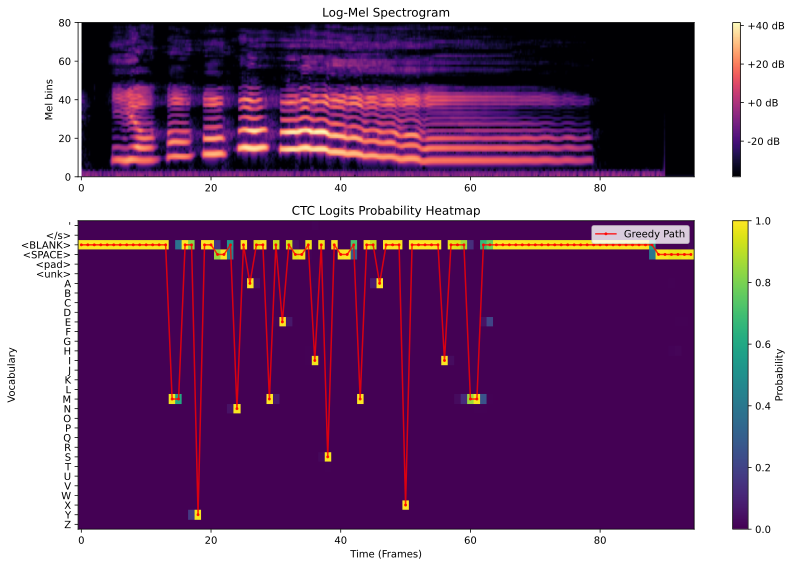

In [16]:
vocab_labels = list(processor.tokenizer.get_vocab().keys())

vocab_labels[processor.tokenizer.pad_token_id] = "<BLANK>"
vocab_labels[processor.tokenizer.word_delimiter_token_id] = "<SPACE>"

reordered_probs = probs[np.argsort(vocab_labels)[::-1]]

fig, (ax_spec, ax) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 2]})

im_spec = ax_spec.imshow(
    log_mel_spectrogram.numpy(), aspect='auto', origin='lower', cmap='magma',
    extent=[0, reordered_probs.shape[1], 0, log_mel_spectrogram.shape[0]]
)
ax_spec.set_title("Log-Mel Spectrogram")
ax_spec.set_ylabel("Mel bins")
plt.colorbar(im_spec, ax=ax_spec, format="%+2.0f dB")

im = ax.imshow(reordered_probs, aspect='auto', origin='lower', cmap='viridis', vmin=0.0, vmax=1.0)

greedy_path = np.argmax(reordered_probs, axis=0)

time_frames = range(reordered_probs.shape[1]) # X-axis
ax.plot(time_frames, greedy_path, color='red', marker='.', markersize=4, 
        linestyle='-', linewidth=1.5, alpha=0.8, label='Greedy Path')

ax.set_yticks(range(len(vocab_labels)))
ax.set_yticklabels(sorted(vocab_labels, reverse=True))
ax.set_xlabel("Time (Frames)")
ax.set_ylabel("Vocabulary")
ax.set_title("CTC Logits Probability Heatmap")

ax_spec.set_xlim(ax.get_xlim())

plt.colorbar(im, ax=ax, label="Probability")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## `3.3. Late Emission`

![](https://www.researchgate.net/publication/395339595/figure/fig4/AS:11431281625413103@1757302841119/Caption-adapted-from-the-CTC-paperGraves-et-al-2006-Framewise-and-CTC-networks.ppm)

It is known that models trained with CTC loss tend to output a probability peak for a character at the very last moment, when the letter is almost finished. That is, the model waits for maximum context before generating the next character. This is achieved by over-generating $\varepsilon$ tokens. 

Adding regularization to paths $A \in \mathcal{A}$ containing a large number of $\varepsilon$ allows improving the quality of the forced alignment annotation at the model's output: [Less Peaky and More Accurate CTC Forced Alignment by Label Priors](https://arxiv.org/pdf/2406.02560v2).

## `3.4. Decoding`

After the sound has passed through the Encoder, the output is a probability matrix, not a finished text. The process of turning these probabilities into the final text is called **decoding**.

### `Greedy Decoding`

The simplest and fastest way to get the text is to choose the token with the maximum probability at each step, ignoring all other options:

1. For each frame $t$, we take the $\arg\max$ over the vocabulary: $$a^{\star}_t = \arg\max\limits_{a \in \hat{V}} p_t(a | X)$$
2. We obtain the raw string (e.g., $h - h - e - e - l - l - \varepsilon - l - o - \  - w - o - r - l - d - \varepsilon$).
3. Apply the collapsing function $B(\cdot) \to$ `hello world`.

Ultimately, we get:

$$ Y_{\text{greedy}} = B(\arg\max_{A \in \mathcal{A}} P(A | X)) $$

<b style='color:red;'>What is the main problem with Greedy decoding?</b>

<details><summary>Answer:</summary>>> 
Formally, CTC Loss optimizes $P(Y|X)$ while Greedy decoding optimizes $P(A|X)$, which is mathematically incorrect. Such a method selects the "best path", but not the "best sequence". Because of this, it often makes mistakes in uncertain parts of the audio.

A simple example where Greedy decoding fails:

| $a \in \hat{V}$ | $p_{1}(a)$ | $p_{2}(a)$ |
| :---: | :---: | :---: |
| a | 0.3 | 0.3 |
| b | 0.1 | 0.2 |
| $\varepsilon$ | 0.6 | 0.5 |

$$ Y_{\text{greedy}} = B(\varepsilon - \varepsilon) = \text{""}$$

$$
P(\text{"a"} | X) = P(a - \varepsilon | X) + P(\varepsilon - a | X) = 0.3 \cdot 0.5 + 0.6 \cdot 0.3 = 0.33 \ge P(\text{""} | X) = 0.6 \cdot 0.5 = 0.3
$$

</details>

### `Prefix Beam Search`

To find the truly best sequence, we need to sum the probabilities of all paths collapsing into a single hypothesis. Beam Search does this approximately, keeping the top $K$ hypotheses at each step.

$$
Y_{beam} \approx \arg\max_{Y} \sum_{A \in B^{-1}(Y)} P(A | X)
$$

Unlike NLP tasks, where each token is unique, in CTC different paths produce the same text.
* Path 1: $\varepsilon - z - z-\varepsilon $
* Path 2: $z-\varepsilon -\varepsilon - \varepsilon$
* Both yield the text `z`.

We need to **merge** the probabilities of paths leading to the same **text hypothesis**, rather than storing them separately.

1.  Initialize the Beam with an empty hypothesis.
2.  For each step $t$:
    *   Take all hypotheses from the previous step's beam.
    *   Try appending every possible token from $\hat{V}$ to them.
    *   Update the probabilities of the text prefixes.
    *   Keep only the top-$K$ hypotheses.

In CTC Beam Search, we must **sum the probabilities of paths** that result in the same prefix. 

The algorithm maintains two states for each prefix: the probability that the prefix ends in $\varepsilon$, and the probability that it ends in a letter $a \in V$. If new paths generate the same prefix, their probabilities are summed.

This method is much more accurate than Greedy, but runs slower $O(M^{\prime} \cdot K \cdot |\hat{V}|)$ compared to $O(M^{\prime} \cdot |\hat{V}|)$ for Greedy decoding.

<img src="./CTC-BeamSearch.svg" width="1000"/>

### `External Language Model`

CTC acoustic models are excellent at recognizing phonetics, but due to the Contextual Independence property, they have a poor grasp of grammar and context: the model might confuse `meet` and `meat` if they sound similar, since the model has no information about the language. To solve this problem, external prior language information can be added to the decoding process via an LM.

The most popular approach is **Beam Search Shallow Fusion**. At each decoding step, the hypothesis probability is modified according to linguistic information:

$$ \text{Score}(Y | X) = \log P(Y | X) + \lambda \log P_{\text{LM}}(Y) + \beta |Y| $$

* $P(Y | X)$ is the probability from the acoustic model.
* $P_{\text{LM}}(Y)$ is the probability from the language model.
* $\lambda$ is the language model weight, which balances the influence of acoustics and language. If $\lambda$ is large, the model will ignore the audio and hallucinate text. If small, acoustic errors will not be corrected.
* $\beta |Y|$ is the **Length Penalty**. Without a length bonus, the model will prefer short sentences, since longer strings always have a lower score.

Integrating a neural network inside Beam Search is inefficient, as it requires computing hypothesis probabilities $\mathcal{K}$ times per decoding step. Therefore, simple **N-gram Language Models** are used for **First-pass decoding**. Their main advantage is that predicting the probability of the next word is executed in $\mathcal{O}(1)$ via hash table lookup.

Let's say we have a sequence of tokens $W = (w_1, w_2, \dots, w_N)$. By the Chain Rule, the true probability of this sequence is:

$$P(w_1, w_2, \dots, w_N) = \prod_{i=1}^{N} P(w_i \mid w_1, \dots, w_{i-1})$$

Estimating the probability of a word given *all* previous history is impossible (for example, the phrase `introduction to machine learning using sklearn` might never have appeared entirely in the training text corpus).

Assume the **Markov property holds: the probability of the next word depends only on the $N-1$ previous words**:
* **Unigram:** $P(w_i) \Longrightarrow P(W) \approx \prod\limits_{i=1}^{N} P(w_i)$ — words are independent and only their frequency is considered.
* **Bigram:** $P(w_i \mid w_{i-1}) \Longrightarrow P(W) \approx \prod\limits_{i=1}^{N} P(w_i \mid w_{i-1})$ — the probability depends on one previous word.
* **Trigram:** $P(w_i \mid w_{i-2}, w_{i-1})  \Longrightarrow P(W) \approx \prod\limits_{i=1}^{N} P(w_i \mid w_{i-1}, w_{i-2})$ — depends on the two previous words.


Probabilities are taken directly from the statistics of text corpora using maximum likelihood estimation through frequency ratios. For example, for Bigram:

$$
P(w_i \mid w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i)}{\text{count}(w_{i-1})}
$$

<b style='color:red;'>What problem might arise when estimating N-gram probabilities?</b>

<details><summary>Answer:</summary>>> 
    
If a pair of words never appeared in the training corpus, then $\log(P(w_{i} \mid w_{i-1})) = -\infty$. 

The simplest way to avoid $-\infty$ is *Laplace smoothing*:

$$
P(w_i \mid w_{i-1}) \approx \frac{\text{count}(w_{i-1}, w_i) + \delta}{\text{count}(w_{i-1}) + \delta |V|}
$$
    
</details>

Example of improvements from using an LM (3-layer LSTM) [Conformer: Convolution-augmented Transformer for Speech Recognition](https://arxiv.org/pdf/2005.08100):

| Method | #Params (M) | WER Without LM: testclean | WER Without LM: testother | WER With LM: testclean | WER With LM: testother |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Hybrid** | | | | | |
| Transformer  | - | - | - | $$2.26$$ | $$4.85$$ |
| **CTC** | | | | | |
| QuartzNet | $$19$$ | $$3.90$$ | $$11.28$$ | $$2.69$$ | $$7.25$$ |
| **LAS** | | | | | |
| Transformer  | $$270$$ | $$2.89$$ | $$6.98$$ | $$2.33$$ | $$5.17$$ |
| Transformer  | - | $$2.2$$ | $$5.6$$ | $$2.6$$ | $$5.7$$ |
| LSTM | $$360$$ | $$2.6$$ | $$6.0$$ | $$2.2$$ | $$5.2$$ |
| **Transducer** | | | | | |
| Transformer | $$139$$ | $$2.4$$ | $$5.6$$ | $$2.0$$ | $$4.6$$ |
| ContextNet(S)  | $$10.8$$ | $$2.9$$ | $$7.0$$ | $$2.3$$ | $$5.5$$ |
| ContextNet(M)  | $$31.4$$ | $$2.4$$ | $$5.4$$ | $$\bf 2.0$$ | $$4.5$$ |
| ContextNet(L)  | $$112.7$$ | $$\bf2.1$$ | $$4.6$$ | $$\bf 1.9$$ | $$4.1$$ |
| **Conformer** | | | | | |
| Conformer(S) | $$10.3$$ | $$\bf 2.7$$ | $$\bf 6.3$$ | $$\bf 2.1$$ | $$\bf 5.0$$ |
| Conformer(M) | $$30.7$$ | $$\bf 2.3$$ | $$\bf 5.0$$ | $$\bf 2.0$$ | $$\bf 4.3$$ |
| Conformer(L) | $$118.8$$ | $$\bf 2.1$$ | $$\bf 4.3$$ | $$\bf 1.9$$ | $$\bf 3.9$$ |

In [17]:
from torchaudio.models.decoder import ctc_decoder, download_pretrained_files

files = download_pretrained_files("librispeech-4-gram")

vocab_dict = processor.tokenizer.get_vocab()
tokens =[k.lower() for k, v in sorted(vocab_dict.items(), key=lambda x: x[1])]

decoder = ctc_decoder(
    lexicon=files.lexicon,
    tokens=tokens,
    lm=files.lm,
    nbest=3,
    beam_size=50,
    lm_weight=2.0,      # How much we trust the Language Model
    word_score=-1.0,    # Penalty for adding a new word (analog of Length Penalty)
    blank_token="<pad>",
    sil_token="|"
)

emissions = log_probs.transpose(0, 1).cpu()
beam_results = decoder(emissions)
best_hyp = beam_results[0][0]

lm_decoded_text = " ".join(best_hyp.words).upper()

print(f"Target Text:            '{text_target}'")
print(f"Greedy Decoding Result: '{decoded_text}'")
print(f"Beam Search + LM Result: '{lm_decoded_text}'")

[" ".join(_.words).upper() for _ in beam_results[0]]

Target Text:            'MY NAME IS MAXIM'
Greedy Decoding Result: 'MY NAME IS MAXIM'
Beam Search + LM Result: 'MY NAME IS MAXIM'


['MY NAME IS MAXIM', 'MY NAME IS MAXIME', 'MY NAME IS MAXIMS']

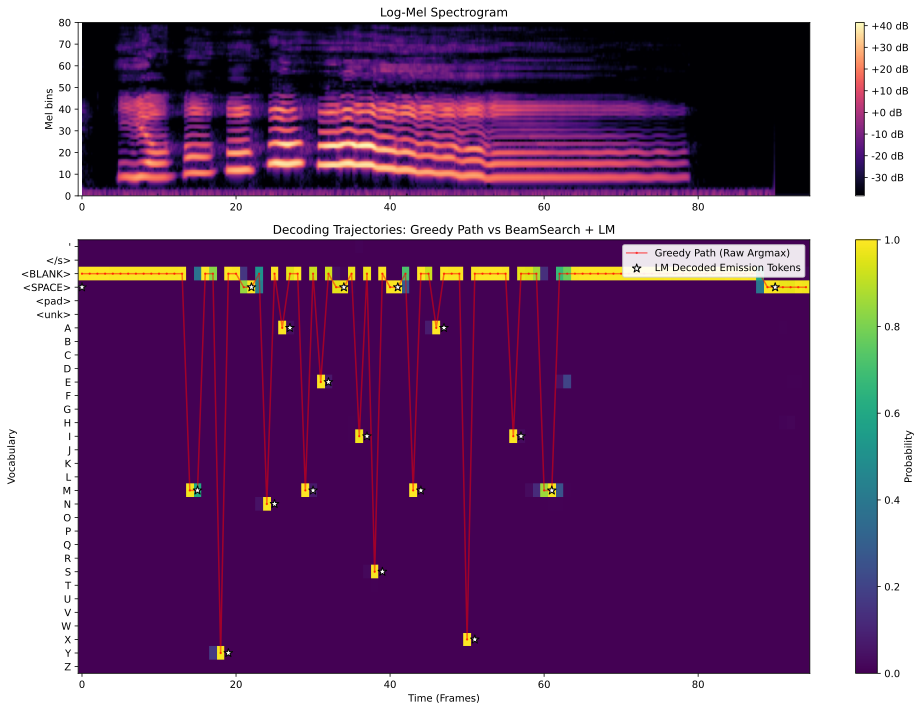

In [18]:
sort_idx = np.argsort(vocab_labels)[::-1]
id_to_y = {original_id: new_y for new_y, original_id in enumerate(sort_idx)}

fig, (ax_spec, ax) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), gridspec_kw={'height_ratios':[1, 2.5]})

im_spec = ax_spec.imshow(
    log_mel_spectrogram.numpy(), aspect='auto', origin='lower', cmap='magma',
    extent=[0, reordered_probs.shape[1], 0, log_mel_spectrogram.shape[0]]
)
ax_spec.set_title("Log-Mel Spectrogram")
ax_spec.set_ylabel("Mel bins")
plt.colorbar(im_spec, ax=ax_spec, format="%+2.0f dB")

im = ax.imshow(reordered_probs, aspect='auto', origin='lower', cmap='viridis', vmin=0.0, vmax=1.0)

time_frames = np.arange(reordered_probs.shape[1])
greedy_path_ids = probs.argmax(axis=0)  # Original token IDs
greedy_y = [id_to_y[tid] for tid in greedy_path_ids]

ax.plot(time_frames, greedy_y, color='red', marker='.', markersize=3, 
        linestyle='-', linewidth=1.5, alpha=0.5, label='Greedy Path (Raw Argmax)')

lm_timesteps = best_hyp.timesteps.tolist()
lm_token_ids = best_hyp.tokens.tolist()

lm_y = [id_to_y[tid] for tid in lm_token_ids]

ax.scatter(lm_timesteps, lm_y, color='white', edgecolor='black', s=80, marker='*',
           zorder=5, label='LM Decoded Emission Tokens')

ax.set_yticks(range(len(vocab_labels)))
ax.set_yticklabels([vocab_labels[i] for i in sort_idx])
ax.set_xlabel("Time (Frames)")
ax.set_ylabel("Vocabulary")
ax.set_title("Decoding Trajectories: Greedy Path vs BeamSearch + LM")

ax_spec.set_xlim(ax.get_xlim())

plt.colorbar(im, ax=ax, label="Probability")
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

### `Rescoring`

To practically take advantage of large language models, **Multi-pass decoding** is used:

**Generation:**
A fast and simple N-gram LM (e.g., 3-gram) is used. Instead of extracting a single best hypothesis from Beam Search, an **N-best list** (e.g., top-10 best options) is obtained.

**Rescoring:**
The LLM recalculates $P_{\text{LM}}(Y)$ strictly for these $10$ options. 

| Hypothesis from N-best list | Beam Score | LLM Score | Total |
| :--- | :--- | :--- | :--- |
| find the last episode of the young pope | -10.0 | -14.0 | -24.0 |
| **find the latest episode of the young pope** | -11.0 | **-10.0** | **-21.0** |
| find the last episode of young popes | -12.0 | -19.0 | -31.0 |

<b style='color:red;'>How do we evaluate whether the current acoustic model can be improved with an LM?</b>

<details><summary>Answer:</summary>>> 

We can estimate the upper bound of the ASR pipeline's quality depending on different LMs:

$$
\text{OracleWER}(\text{Hypotheses}, \text{Reference}) = \min\limits_{H \in \text{Hypotheses}} WER(H, \text{Reference})
$$
    
**Oracle WER** is the theoretically best WER that can be obtained if we always choose the optimal hypothesis from the generated N-best list. A large difference between Oracle WER and the current pipeline's quality indicates that the Rescoring LM is not of sufficient quality.
</details>

Example of the impact of Rescoring on the ASR pipeline [Effect and Analysis of Large-scale Language Model Rescoring on Competitive ASR Systems](https://arxiv.org/pdf/2204.00212):

| Model | Baseline (Conformer-T) | BERT-base (uncased) | +scratch | +finetune | +context | +finetune +context | RoBERTa-base | +scratch | +finetune | +context | +finetune +context | BERT-large (uncased) | +scratch | +finetune | +context | +finetune +context | RoBERTa-large | +scratch | +finetune | +context | +finetune +context | Oracle (16-best) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Best $\lambda$** | $-$ | $0.05$ | $0.15$ | $0.15$ | $0.10$ | $0.20$ | $0.10$ | $0.15$ | $0.20$ | $0.15$ | $0.20$ | $0.05$ | $0.15$ | $0.25$ | $0.10$ | $0.15$ | $0.10$ | $0.10$ | $0.25$ | $0.10$ | $0.15$ | $-$ |
| **SWB** | $5.3$ | $5.3$ | $5.2$ | $\bf 5.0$ | $5.2$ | $\bf 5.0$ | $5.2$ | $5.3$ | $\bf 5.1$ | $5.2$ | $\bf 5.1$ | $5.2$ | $5.2$ | $\bf 5.1$ | $5.2$ | $\bf 5.1$ | $5.1$ | $5.2$ | $5.2$ | $5.1$ | $\bf 5.0$ | $2.6$ |
| **CH** | $8.9$ | $8.8$ | $8.7$ | $\bf 8.5$ | $8.6$ | $\bf 8.5$ | $8.7$ | $8.6$ | $8.6$ | $8.6$ | $\bf 8.5$ | $8.8$ | $8.7$ | $8.5$ | $8.6$ | $\bf 8.4$ | $8.6$ | $8.6$ | $\bf 8.5$ | $\bf 8.5$ | $\bf 8.5$ | $4.5$ |